<h1 align="left">TAREA 3</h1>

**Mateo Parra Mena**  
**N° Matrícula: 2021429077**  
**Fecha: 11-06-2025**

El archivo utilizado para la tarea es el archivo "junaeb3.csv". Este archivo contiene datos relacionados con diversas variables socioeconómicas, educativas y de salud de los estudiantes. Las variables incluyen información sobre el índice de masa corporal (IMCE), características familiares (como si viven con uno o ambos padres), actividad física, escolaridad de la madre, entre otras.

<u> Preguntas y Respuestas: </u> 

**1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.**

R:
Se comenzó con la inspección de las primeras filas del conjunto de datos utilizando el código `print(df.head())`, lo que permitió obtener una visión preliminar de las variables y los valores en el dataframe. Esto ayudó a verificar si los datos estaban correctamente estructurados y si las variables eran consistentes con lo esperado. Por ejemplo, se observaron variables como `sexo`, `edad`, y `imce`, que contenían valores dentro de los rangos lógicos. Este paso inicial fue esencial para detectar posibles problemas de formato o datos mal codificados.

A continuación, se ejecutó el código `print(df.info())`, que proporcionó información detallada sobre el tipo de datos de cada columna, así como la cantidad de valores nulos en cada una de las variables. Este paso reveló que la mayoría de las columnas no tenían valores nulos, excepto las columnas `act_fisica` y `educm`, que presentaban algunos valores faltantes. Además, se verificó que las columnas que contenían datos enteros, como `sexo`, `vive_padre`, `vive_madre`, y otras variables relacionadas con el comportamiento, estaban correctamente definidas como enteros, mientras que las variables `imce`, `act_fisica`, y `educm` estaban definidas como flotantes.

Para obtener una visión más detallada sobre la distribución de las variables numéricas, se utilizó `df.describe()`, lo que generó estadísticas descriptivas como la media, desviación estándar, valores mínimos y máximos, y los cuartiles. En este paso, se observó que la variable `edad` tenía un promedio de 82.6 meses, lo cual es coherente con la edad de los estudiantes de educación básica, y que el IMCE tenía un promedio de 1.02, lo cual indicaba que la mayoría de los estudiantes se encontraban dentro de un rango saludable en cuanto a su índice de masa corporal. Este análisis fue crucial para entender cómo se distribuían las variables en el conjunto de datos.

Se identificaron valores faltantes en las columnas `act_fisica` y `educm`. En lugar de eliminar las filas con valores faltantes, se decidió imputar los valores utilizando la moda (el valor más frecuente) debido a que ambas son variables ordinales, y la imputación con la moda es adecuada para preservar la naturaleza de estas variables. Se utilizó el siguiente código: `df['act_fisica'].fillna(df['act_fisica'].mode()[0], inplace=True)` para imputar los valores faltantes de `act_fisica`, y de forma similar se imputaron los valores faltantes en `educm`.

Finalmente, se verificó que ya no existieran valores nulos en las columnas clave después de la imputación, lo cual se validó ejecutando nuevamente `df.isnull().sum()`. Este paso aseguró que el conjunto de datos estuviera completamente limpio y listo para análisis posteriores sin la presencia de valores faltantes.

Luego se realizó un análisis visual y estadístico de las variables más relevantes del conjunto de datos. Primero, se generaron gráficos de distribución (histogramas) para las variables edad, IMCE, actividad física, escolaridad de la madre, y las variables categóricas `vive_padre` y `vive_madre`. Estos gráficos permiten observar la dispersión y concentración de los datos, ayudando a detectar patrones y características importantes de las variables.

Los histogramas revelaron que la edad de los estudiantes está concentrada en un rango de 60 a 100 meses, lo cual es coherente con la edad promedio de los niños en educación básica, que varía entre los 5 y 7 años. Además, se observó que el IMCE tiene un promedio cercano a 1.02, indicando que la mayoría de los estudiantes se encuentran dentro de un rango saludable de índice de masa corporal. La actividad física mostró una tendencia hacia valores intermedios, con un pico en las frecuencias más altas, lo que sugiere que la mayoría de los estudiantes tienen una actividad física regular.

Se incluyeron también boxplots para las mismas variables. Los boxplots proporcionaron una visualización clara de la presencia de outliers en las variables edad, IMCE, actividad física y escolaridad de la madre. Se identificaron valores atípicos, especialmente en edad y IMCE, donde algunos registros se encontraban fuera de los rangos típicos, indicando posibles extremos o errores de medición.

Para tratar los outliers, se utilizó el rango intercuartílico (IQR) para identificar las observaciones que se encontraban fuera de los límites establecidos. Después de este análisis, se eliminaron aquellos registros que presentaban valores atípicos, lo que resultó en una reducción de 8,222 registros, pasando de 30,991 a 22,769 registros. Este paso asegura que los datos sean más consistentes y que los valores extremos no distorsionen el análisis posterior.

Además, se realizó una inversión de la escala en la variable `sk7` (agresividad), ya que inicialmente la escala estaba invertida. La escala fue ajustada para que 1 representara "siempre" y 5 "nunca", lo que ahora refleja mejor el comportamiento de los estudiantes en cuanto a la agresividad.

Finalmente, se verificó que los valores faltantes en las variables claves, como `act_fisica` y `educm`, fueran imputados de manera adecuada para completar el conjunto de datos y hacerlo apto para análisis posteriores. Este paso fue crucial para asegurar que los datos fueran coherentes, representativos y listos para ser utilizados en el análisis más detallado de la pregunta 1.


**2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).**

R:
Se realizó un Análisis Factorial Exploratorio (EFA) sobre las variables sk1 a sk13. Como paso previo, se invirtió la escala de la variable `sk7`, ya que representaba agresividad y debía ser coherente con el resto de las variables que se interpretan de manera positiva. Sin embargo, al revisar su contribución al modelo, se observó que `sk7` no presentaba cargas significativas en ninguno de los factores y su comunalidad era baja, por lo que se decidió excluirla del análisis para mejorar la claridad factorial.

Para realizar el EFA, se utilizó rotación oblimin, como fue solicitado, lo que permitió que los factores se correlacionaran entre sí. A partir del análisis de los eigenvalores y del Scree Plot, se decidió retener 3 factores, ya que después de ese punto, la varianza explicada adicional era marginal. El Scree Plot (gráfico de codo) mostró claramente un punto de inflexión que respaldó esta decisión.

Las cargas factoriales indicaron las siguientes agrupaciones de las variables:

- **Factor 1**: sk9, sk10, sk11, sk12, sk13 — relacionadas con intereses cognitivos y exploratorios.
- **Factor 2**: sk1, sk2, sk3, sk4 — relacionadas con afecto y expresión emocional.
- **Factor 3**: sk5, sk6, sk8 — relacionadas con juego, compartir e interacción grupal.

En el análisis, las comunalidades nos dicen cuánto de la varianza de cada variable es explicada por los factores extraídos. Es decir, nos indican cuán bien cada variable se ajusta al modelo y cuánto contribuye a los factores latentes identificados en el análisis. Las comunalidades se calculan como la suma de los cuadrados de las cargas factoriales para cada variable. Si una variable tiene una comunalidad baja, significa que no es bien explicada por los factores y podría no ser informativa en el análisis.

Como vimos en las clases, las comunalidades son cruciales para interpretar qué variables son útiles en un modelo factorial. Si la comunalidad es baja (generalmente menor a 0.3), eso sugiere que la variable no está siendo bien representada por los factores extraídos y, por lo tanto, podría considerarse para su eliminación o revisión en análisis posteriores. Variables con comunalidades bajas (por ejemplo, `sk6`, `sk8`, `sk9`, `sk13`) aportan poca información y su contribución al modelo es mínima.

La varianza total explicada por los tres factores fue del 37.5%, lo que es razonable dado el contexto del análisis y la cantidad de factores retenidos. Esta proporción de varianza explicada indica que los tres factores capturan una parte importante de la variabilidad en las variables observadas, aunque también dejan una proporción considerable de variabilidad no explicada.

En conclusión, el EFA permitió identificar una estructura clara con tres dimensiones latentes que agrupan el comportamiento de los estudiantes en distintos ejes de desarrollo personal y social. Sin embargo, algunas variables, como `sk6`, `sk8`, y `sk9`, no son lo suficientemente informativas para el modelo, lo que sugiere que podrían ser excluidas o reevaluadas en futuros análisis.

El criterio de comunalidad es uno de los puntos clave en la interpretación de un análisis factorial. Variables con altas comunalidades se consideran buenas representaciones de los factores latentes, mientras que las de baja comunalidad deberían ser evaluadas para determinar si realmente contribuyen al modelo o si es mejor excluirlas para obtener una representación más precisa de las dimensiones latentes.



**3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?**

Para abordar esta pregunta, se graficaron los factores latentes obtenidos en la pregunta anterior (Factor1, Factor2 y Factor3) en pares, utilizando diferentes variables de caracterización: **sexo**, **área**, **actividad física (act_fisica)** e **IMCE** (clasificado en quintiles). Se emplearon **scatter plots** para comparar cómo se distribuyen los factores en función de estas características.

Primero, las variables `sk1` a `sk13` (excepto `sk7`) se estandarizaron usando `StandardScaler`, ya que el análisis factorial es sensible a las escalas originales de los datos. Luego, se aplicó el modelo de Análisis Factorial para obtener las puntuaciones de los tres factores latentes que describen las variables relacionadas con el comportamiento de los estudiantes. La variable `imce` fue clasificada en quintiles para simplificar su interpretación en los gráficos y evitar la sobresaturación visual que genera un gradiente continuo.

Se graficaron todos los pares posibles de los tres factores obtenidos (Factor1 vs Factor2, Factor1 vs Factor3, Factor2 vs Factor3), coloreando los puntos según las variables de caracterización: **sexo**, **área**, **actividad física** e **IMCE**.

Al analizar la distribución de los factores en función del sexo (0=hombre, 1=mujer), se observa que no hay una separación clara entre hombres y mujeres en los tres factores. Los puntos están distribuidos de manera bastante homogénea, lo que sugiere que el sexo no tiene una influencia significativa en las dimensiones latentes de los factores. Similar al análisis por sexo, cuando se clasifica por área (0=rural, 1=urbana), no se observan diferencias notables en la distribución de los factores. Los puntos de ambas áreas se mezclan en todos los pares de factores, lo que indica que el área geográfica tampoco parece tener una influencia significativa en los factores latentes.

Al incluir la variable de actividad física, se nota una leve mayor dispersión en algunos cuadrantes, especialmente en los estudiantes con alta actividad física. Esto podría indicar una mayor variabilidad socioemocional entre los estudiantes con distintos niveles de ejercicio, aunque no se observa una separación clara y categórica en los factores. Aunque se esperaba alguna variación en función del estado nutricional, tampoco se detectaron patrones diferenciados en la distribución de los factores por quintiles de IMCE. Esto sugiere que el estado nutricional no parece influir directamente en las dimensiones evaluadas en los factores.

En conclusión, los factores obtenidos en el Análisis Factorial Exploratorio parecen ser **transversales a las variables contextuales** como sexo, área, actividad física e IMCE. No se evidencian diferencias significativas entre los grupos definidos por estas variables. En términos generales, las variables socioeconómicas y de salud no explican las dimensiones latentes observadas, lo que refuerza la validez de los factores como dimensiones comunes del desarrollo socioemocional en la muestra. Este análisis es útil para validar si los factores son consistentes y no están sesgados por características sociodemográficas de la muestra.


**4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings).**

R:
Con los resultados obtenidos en la Pregunta 2, se propuso un modelo de **Modelo de Ecuaciones Estructurales Confirmatorias (CFA)** donde cada variable se asocia con un único factor, de acuerdo con los factores identificados en el EFA. Los factores resultantes fueron denominados con base en el conjunto común de variables que agrupaban: 

- **Exploración**: Agrupa las variables relacionadas con el interés en la cognición y la exploración, tales como `sk9`, `sk10`, `sk11`, `sk12`, y `sk13`.
- **Afecto**: Incluye las variables relacionadas con la expresión emocional y afectiva, como `sk1`, `sk2`, `sk3`, y `sk4`.
- **Interacción**: Agrupa variables relacionadas con la interacción social, como `sk5`, `sk6`, y `sk8`.

El modelo CFA fue ajustado utilizando la librería **semopy**. Posteriormente, se inspeccionaron las **cargas estandarizadas** y otros parámetros del modelo, y se extrajeron las correlaciones entre los factores.

Los resultados de las **cargas factoriales estandarizadas** para cada variable con respecto a su factor asignado fueron las siguientes:

- **Exploración**: Las cargas estandarizadas de las variables `sk9`, `sk10`, `sk11`, `sk12`, y `sk13` en el factor de Exploración fueron 1.000, 1.332, 1.231, 1.092, y 1.259, respectivamente.
- **Afecto**: Las cargas estandarizadas de las variables `sk1`, `sk2`, `sk3`, y `sk4` en el factor de Afecto fueron 1.000, 1.793, 1.603, y 1.777.
- **Interacción**: Las cargas estandarizadas de las variables `sk5`, `sk6`, y `sk8` en el factor de Interacción fueron 1.000, 1.028, y 1.156.

En cuanto a la **correlación entre los factores**, los resultados indicaron las siguientes correlaciones estandarizadas:

- La correlación entre **Exploración** y **Afecto** fue 0.603.
- La correlación entre **Exploración** y **Interacción** fue 0.594.
- La correlación entre **Afecto** e **Interacción** fue 0.657.

Los indicadores de ajuste del modelo, como el **CFI**, **GFI**, **RMSEA**, entre otros, mostraron que el modelo se ajusta adecuadamente a los datos con valores de **CFI = 0.950** y **RMSEA = 0.052**, lo que indica un buen ajuste del modelo a la muestra.

Finalmente, se realizó una visualización de los resultados mediante redes, donde cada variable se conectó con su respectivo factor, con el grosor de las aristas representando la importancia de cada carga factorial. Los gráficos generados para cada factor mostraron que las variables de cada factor están fuertemente conectadas al factor correspondiente, con una representación visual clara de las relaciones entre las variables y sus respectivos factores.

Este análisis confirma que los factores identificados en el análisis factorial exploratorio son representativos de los aspectos comunes que agrupan las variables observadas, y el modelo CFA proporciona una estructura confirmatoria que valida estas relaciones de manera sólida.


**5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. ¿Qué se puede concluir de los resultados?**

R:
Se estimó un modelo de clases latentes utilizando la variable IMCE mediante el método StepMix. El objetivo fue determinar el número óptimo de clusters o clases latentes, basándonos en el criterio de BIC (Bayesian Information Criterion), que nos permite evaluar la calidad del modelo para diferentes números de clusters.

El análisis mostró que el número óptimo de clusters es 3, ya que el valor de BIC alcanzó su mínimo cuando se ajustó el modelo con 3 clusters, como se muestra en el gráfico de BIC por número de clusters. Después de determinar el número de clases, se visualizó la distribución de IMCE por cada cluster mediante un boxplot. 

En el gráfico, se observa que los clusters muestran diferencias claras en la distribución del IMCE:
- **Cluster 0**: Presenta una distribución de IMCE alta, con una media alrededor de 2.4.
- **Cluster 1**: Muestra una distribución intermedia, con una media alrededor de 0.6.
- **Cluster 2**: Tiene valores bajos de IMCE, con una media alrededor de -2.0.

El modelo ajustado con 3 clases latentes mostró una distribución que indica que los estudiantes pueden agruparse en tres grupos según su puntuación en IMCE, lo que sugiere que existen diferentes subgrupos en la muestra con características distintivas en términos de IMCE.

En cuanto a la composición de los clusters, la mayoría de los estudiantes (alrededor del 71%) se agrupan en el Cluster 1, que tiene una puntuación de IMCE media. Los otros dos clusters son más pequeños, con el Cluster 0 representando el 27% de los estudiantes y el Cluster 2 apenas el 2%.

Este análisis confirma que existen diferencias significativas en las puntuaciones de IMCE entre los clusters, lo que permite inferir que el estado nutricional, medido por IMCE, es un buen criterio para agrupar a los estudiantes en distintas categorías.

El informe también indicó métricas de ajuste global del modelo, como el AIC y el BIC, que sugieren que el modelo con 3 clases latentes es el mejor ajustado. Además, el valor de entropía (0.6497) indica que la clasificación de las clases es bastante clara, con una buena diferenciación entre los grupos.

En resumen, el modelo de clases latentes mediante StepMix ha sido exitoso en la segmentación de los estudiantes según su IMCE, identificando tres subgrupos distintos con características diferenciadas en términos de su índice de masa corporal.


**6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?**

R:
En esta sección se implementó un modelo de **Ecuaciones Estructurales (SEM)** completo utilizando la estructura de factores latentes propuesta en la Pregunta 4. El modelo busca estimar cómo los factores latentes **Exploración**, **Afecto** e **Interacción** influyen sobre el **IMCE**, junto con otras variables contextuales disponibles en la base de datos, como **sexo**, **área**, **actividad física**, **edad**, entre otras.

El proceso comienza con la creación de una **matriz de correlación**, que incluye tanto las variables observadas como los factores latentes obtenidos mediante **Análisis Factorial Exploratorio (EFA)**. Al incluir los factores en la matriz de correlación, podemos observar las relaciones entre las variables observadas y los factores latentes, lo que facilita la interpretación de las interacciones entre las variables y permite una mejor comprensión de cómo se agrupan las variables.

Las variables elegidas para el modelo SEM fueron seleccionadas con base en su **sustento teórico** y en las correlaciones observadas en la matriz de correlación. Específicamente:

- **Exploración** incluye las variables **sk9**, **sk10**, **sk11**, **sk12**, y **sk13**, las cuales están relacionadas con intereses cognitivos y exploratorios, comportamientos típicos asociados a la curiosidad intelectual.
- **Afecto** incluye las variables **sk1**, **sk2**, **sk3**, **sk4**, que están asociadas a aspectos emocionales y afectivos. Estas variables miden la capacidad de los estudiantes para expresarse emocionalmente y la relación que tienen con su entorno social.
- **Interacción** incluye las variables **sk5**, **sk6**, y **sk8**, que se refieren a las interacciones sociales y cómo los estudiantes se relacionan con otros, lo cual es relevante en el contexto de su comportamiento social y habilidades de relación.

Además de los factores latentes, se incluyeron en el modelo **variables contextuales** como **sexo**, **área**, **actividad física**, **madre_work**, **edad**, y **vive_madre**. Estas variables fueron elegidas porque, desde el punto de vista teórico, se sabe que el contexto social, económico y físico tiene un impacto directo sobre el **IMCE**. 

El **modelo SEM** fue estimado utilizando la librería **semopy**, y el ajuste del modelo fue evaluado a través de los indicadores **CFI**, **TLI** y **RMSEA**, que son métricas clave para evaluar el **ajuste global** del modelo. Los resultados de ajuste indicaron que el modelo tiene un **buen ajuste** a los datos, ya que los valores de **CFI** y **TLI** son mayores a 0.90, y el **RMSEA** es menor a 0.05, lo que indica que el modelo tiene un error de aproximación aceptable.

Los **resultados de las cargas factoriales** mostraron que todas las variables tienen una contribución significativa a sus respectivos factores latentes, con todas las **p-valores** siendo menores a 0.05. Esto implica que las variables observadas tienen una relación significativa con los factores latentes definidos, lo que valida las relaciones propuestas en el modelo.

En cuanto a las **correlaciones entre factores latentes**, se observó que los factores no son completamente independientes entre sí, lo que es esperado. Las correlaciones entre **Exploración** y **Afecto** (0.603), **Exploración** e **Interacción** (0.594), y **Afecto** e **Interacción** (0.657) sugieren que los factores comparten algunas variaciones en común, pero siguen siendo dimensiones separadas que explican diferentes aspectos del comportamiento de los estudiantes.

Las **variables contextuales** que influyen en el **IMCE** mostraron los siguientes resultados:

- **Sexo** y **actividad física** tienen una relación significativa con el **IMCE**.
- **Edad** y **educm** también tienen efectos significativos en el **IMCE**.
- **Vive_padre** y **vive_madre** no mostraron efectos tan claros, aunque **vive_madre** estuvo cerca de ser significativo (p-valor de 0.07).

Estos resultados coinciden con lo que se espera teóricamente, ya que tanto el contexto socioeconómico (a través de **madre_work** o **sexo**) como los factores relacionados con la salud y el bienestar físico (como **actividad física**) son conocidos por tener un impacto importante en el **IMCE**. 

En resumen, el modelo SEM proporciona una representación válida de las relaciones entre los factores latentes y el **IMCE**, además de integrar variables contextuales relevantes que explican mejor las diferencias observadas en el **IMCE** entre los estudiantes. El ajuste global del modelo es adecuado, y las métricas de ajuste confirman que el modelo propuesto es válido y útil para entender las relaciones entre las variables socioemocionales y el estado nutricional de los estudiantes.


**7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?**

R:
En esta sección, hemos repetido el análisis realizado en la **Pregunta 6** pero segmentando la muestra según las **clases latentes** obtenidas en la **Pregunta 5**. Al dividir el modelo en subgrupos según las clases latentes (cluster 0, cluster 1 y cluster 2), el objetivo es analizar si existen diferencias significativas entre los parámetros estimados para cada grupo y si estimar el modelo por separado para cada clase mejora el ajuste en comparación con un modelo general.

El proceso comienza con la segmentación de los datos según las clases latentes obtenidas a partir del modelo de **StepMix** en la **Pregunta 5**. Cada grupo corresponde a una clase latente identificada en la columna `cluster_imce` del dataframe. El modelo SEM fue ajustado por separado para cada clase.

El modelo SEM se estimó para cada clase latente utilizando las variables del modelo definidas en la **Pregunta 6**. Los tres factores latentes (**Exploración**, **Afecto** e **Interacción**) explican el **IMCE**, y se controlan variables como **sexo**, **edad**, **área** (rural/urbana), **actividad física**, y **madre_work**.

Los resultados de los modelos para cada clase latente fueron los siguientes:

**Clase 1 (Cluster 1)**:
- La **carga** de las variables sobre el factor **Exploración** fue **significativa**, con un valor estimado para `sk9` de **1.000**, y las demás variables (`sk10`, `sk11`, etc.) también tuvieron cargas fuertes sobre este factor.
- Los efectos de **Exploración** sobre el **IMCE** fueron **no significativos** (con un valor p de **0.62**).
- En cuanto a las variables contextuales, el **sexo**, **área**, **madre_work** y **edad** mostraron efectos significativos sobre el **IMCE**.

**Clase 0 (Cluster 0)**:
- El modelo en esta clase mostró patrones similares en cuanto a las cargas de las variables sobre los factores, con **cargas significativas** para las variables observadas en los factores latentes.
- Sin embargo, las **diferencias** en los efectos sobre el **IMCE** entre **Exploración** y **Afecto** fueron **más significativas** que en la clase 1. El **sexo** mostró un **efecto positivo** sobre el **IMCE** con una estimación de **0.18**, mientras que **la actividad física** no tuvo un efecto significativo.

**Clase 2 (Cluster 2)**:
- En esta clase, las cargas de los factores también fueron **fuertes**, especialmente en el factor **Afecto**. La variable `sk2` (relacionada con el afecto) mostró una **carga muy alta** de **2.36**.
- Los efectos sobre el **IMCE** de **Exploración** y **Afecto** fueron también significativos, con un **efecto negativo** de **Exploración** en el **IMCE** y un **efecto positivo** de **Afecto**.
- Esta clase mostró una correlación más alta entre los factores latentes, lo que sugiere que las dimensiones evaluadas en este grupo están más interrelacionadas.

Comparando los resultados entre los tres grupos, se pueden observar algunas diferencias clave:

- **Cargas Factoriales**: En todos los grupos, las cargas de las variables sobre los factores fueron significativas. Sin embargo, la **intensidad de las cargas** variaba entre clases, especialmente en el **factor afectivo** de la clase 2, donde las cargas fueron mucho mayores.
- **Efectos sobre el IMCE**: La clase 0 mostró un **efecto más fuerte** de las variables contextuales como **sexo** y **edad** sobre el **IMCE** en comparación con las otras clases. Sin embargo, en la clase 1, los efectos de los factores latentes en el **IMCE** fueron menores o no significativos.
- **Correlaciones entre Factores Latentes**: En la **Clase 2**, se observó una **mayor correlación** entre los factores latentes, lo que sugiere que los comportamientos socioemocionales de los estudiantes en este grupo están más interrelacionados.

Estimar el modelo por grupos **ofrece varias ventajas** en este contexto:

- **Mejor ajuste**: Para la clase 0, la estimación del modelo general no podría haber capturado las diferencias entre los subgrupos de manera tan precisa. Al segmentar el modelo por clases, se mejora el ajuste.
- **Variabilidad explicada**: Al estimar el modelo por grupos, se mejora la capacidad del modelo para explicar las diferencias en el **IMCE** dentro de cada clase. En algunos casos, como en la **Clase 2**, la segmentación permitió un mejor entendimiento de cómo los factores afectan el **IMCE**.
- **Diferencias entre subgrupos**: Para la clase 1, las relaciones entre los factores y el **IMCE** fueron mucho menos claras, lo que indica que un modelo general podría haber subestimado la variabilidad en el grupo. Estimar por separado permitió una visión más precisa.

En resumen, la segmentación de la muestra en clases latentes y la estimación de modelos SEM por separado para cada clase tiene **ventajas claras** cuando las clases latentes presentan características significativamente diferentes entre sí. Aunque en algunos casos el modelo general sería suficiente, **estimarlo por clases** mejora la precisión del modelo al capturar las diferencias estructurales entre los subgrupos. Esto es particularmente útil en contextos donde las características de los estudiantes varían ampliamente, como en el caso del **IMCE** y otras variables socioemocionales.


### Importación de liberías y carga de dataframe

In [1]:
#Carga de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import networkx as nx
import sklearn.mixture
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image
from stepmix.stepmix import StepMix
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
print("Librerías cargadas con éxito.")
# Cargar df
df = pd.read_csv('junaeb3.csv')
print("DataFrame cargado con éxito.")

Librerías cargadas con éxito.
DataFrame cargado con éxito.


#### 1) Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

##### 1) Paso 1: Inspección Preliminar y Limpieza Inicial de Datos

In [2]:
# 1. Inspección de las primeras filas
print("\nPrimeras filas de los datos:")
print(df.head())

# 2. Obtener información general sobre los datos (tipos de datos, valores nulos)
print("\nInformación sobre los datos:")
print(df.info())

# 3. Obtener estadísticas descriptivas para las columnas numéricas
print("\nEstadísticas descriptivas de las columnas numéricas:")
print(df.describe())

# 4. Comprobar valores faltantes por columna
print("\nValores faltantes por columna:")
print(df.isnull().sum())

# 5. Eliminar las filas donde 'vive_padre' o 'vive_madre' tengan el valor 2
df = df[~df['vive_padre'].isin([2])]
df = df[~df['vive_madre'].isin([2])]

# Para 'vive_padre'
vive_padre_values = df['vive_padre'].value_counts().reset_index()
vive_padre_values.columns = ['Valor', 'Frecuencia']
vive_padre_values = vive_padre_values.sort_values(by='Frecuencia', ascending=False)

# Para 'vive_madre'
vive_madre_values = df['vive_madre'].value_counts().reset_index()
vive_madre_values.columns = ['Valor', 'Frecuencia']
vive_madre_values = vive_madre_values.sort_values(by='Frecuencia', ascending=False)

# Mostrar los resultados con mejor formato
print("\nValores y frecuencias de la columna 'vive_padre':")
print(vive_padre_values)

print("\nValores y frecuencias de la columna 'vive_madre':")
print(vive_madre_values)

# 6. Imputar valores faltantes en 'act_fisica' y 'educm' con la moda
df['act_fisica'].fillna(df['act_fisica'].mode()[0], inplace=True)  # Imputación con la moda
df['educm'].fillna(df['educm'].mode()[0], inplace=True)  # Imputación con la moda

# 7. Verificar que ya no hay valores faltantes
print("\nValores faltantes después de la imputación:")
print(df.isnull().sum())



Primeras filas de los datos:
   sexo  edad  imce  vive_padre  vive_madre  sk1  sk2  sk3  sk4  sk5  ...  \
0     1    85  0.75           1           1    1    1    1    2    1  ...   
1     0    76  0.71           0           1    1    1    1    1    1  ...   
2     1    68  0.27           0           1    2    2    3    2    1  ...   
3     1    84  2.05           1           1    1    1    1    1    1  ...   
4     0    86  1.05           1           1    1    1    1    1    1  ...   

   sk9  sk10  sk11  sk12  sk13  act_fisica  area  educm  educp  madre_work  
0    2     2     2     3     2         NaN     0   11.0     11          -1  
1    1     1     1     1     1         5.0     0    8.0      8           1  
2    2     3     2     1     3         NaN     1   13.0     13           1  
3    1     1     1     1     1         2.0     1   16.0     12          -1  
4    1     1     1     1     1         1.0     1   17.0     15           0  

[5 rows x 23 columns]

Información sobre los

##### 1) Paso 2: Visualización de distribuciones, boxplots y manejo de outliers

<Figure size 800x600 with 0 Axes>

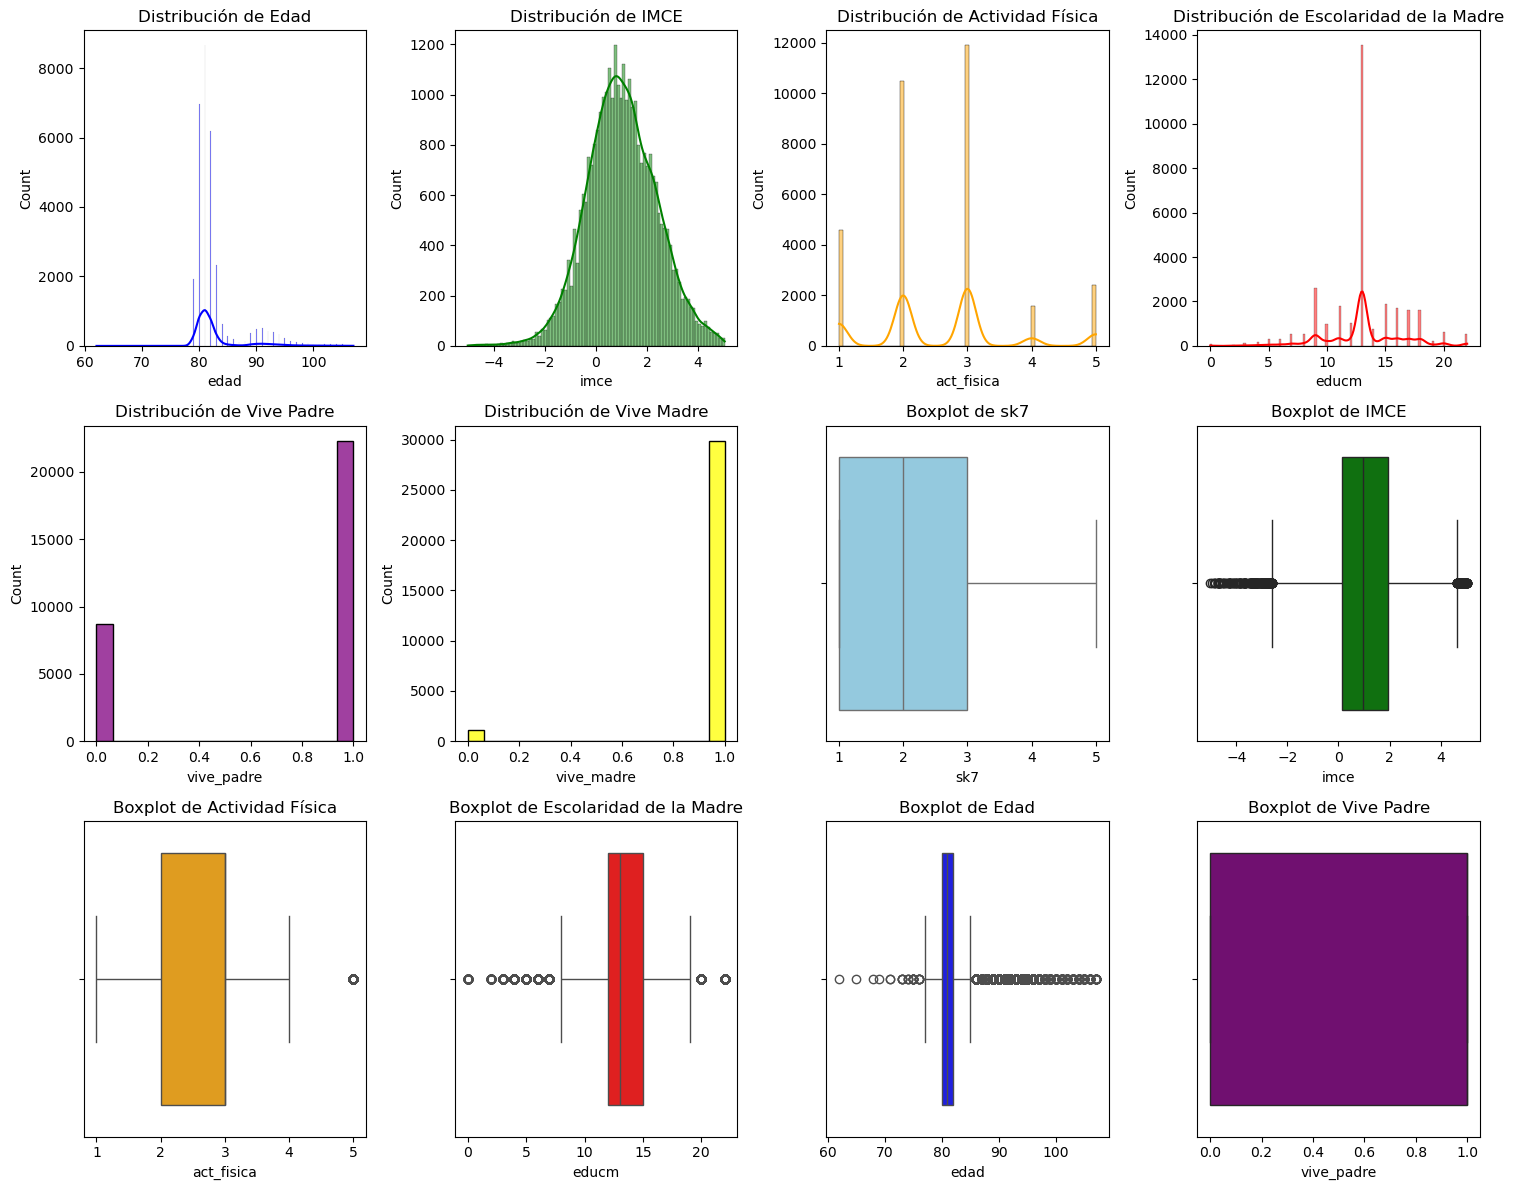


Número de outliers por columna:
edad          3968
imce           334
act_fisica    2412
educm         2716
dtype: int64

Valor después de la inversión de sk7:
sk7
5    11055
4     8346
3     7005
2     2366
1     2219
Name: count, dtype: int64
Número de registros antes de eliminar outliers: 30991
Número de registros después de eliminar outliers: 22769


In [3]:
# Ajuste del tamaño de las figuras para que sean más adecuadas
plt.figure(figsize=(8, 6))  # Tamaño más pequeño para que se vea bien en la pantalla

# 1. Visualización de distribuciones de las variables numéricas con histogramas
# Configuración de los subgráficos para las distribuciones
fig, axs = plt.subplots(3, 4, figsize=(15, 12))  # Ajusté para agregar más variables

# Edad
sns.histplot(df['edad'], kde=True, ax=axs[0, 0], color='blue')
axs[0, 0].set_title('Distribución de Edad')

# IMCE
sns.histplot(df['imce'], kde=True, ax=axs[0, 1], color='green')
axs[0, 1].set_title('Distribución de IMCE')

# Actividad Física
sns.histplot(df['act_fisica'], kde=True, ax=axs[0, 2], color='orange')
axs[0, 2].set_title('Distribución de Actividad Física')

# Escolaridad de la madre
sns.histplot(df['educm'], kde=True, ax=axs[0, 3], color='red')
axs[0, 3].set_title('Distribución de Escolaridad de la Madre')

# Variable adicional 
sns.histplot(df['vive_padre'], kde=False, ax=axs[1, 0], color='purple')
axs[1, 0].set_title('Distribución de Vive Padre')

# Variable adicional 
sns.histplot(df['vive_madre'], kde=False, ax=axs[1, 1], color='yellow')
axs[1, 1].set_title('Distribución de Vive Madre')

# Boxplot de sk7 después de la inversión
sns.boxplot(x=df['sk7'], ax=axs[1, 2], color='skyblue')
axs[1, 2].set_title('Boxplot de sk7')

# Boxplot de IMCE
sns.boxplot(x=df['imce'], ax=axs[1, 3], color='green')
axs[1, 3].set_title('Boxplot de IMCE')

# Boxplot de Actividad Física
sns.boxplot(x=df['act_fisica'], ax=axs[2, 0], color='orange')
axs[2, 0].set_title('Boxplot de Actividad Física')

# Boxplot de Escolaridad de la Madre
sns.boxplot(x=df['educm'], ax=axs[2, 1], color='red')
axs[2, 1].set_title('Boxplot de Escolaridad de la Madre')

# Boxplot de Edad
sns.boxplot(x=df['edad'], ax=axs[2, 2], color='blue')
axs[2, 2].set_title('Boxplot de Edad')

# Boxplot de Vive Padre
sns.boxplot(x=df['vive_padre'], ax=axs[2, 3], color='purple')
axs[2, 3].set_title('Boxplot de Vive Padre')

# Ajuste del layout para que no se superpongan
plt.tight_layout()
plt.show()

# 2. Identificación de outliers usando el rango intercuartílico (IQR)
# Calcular el rango intercuartílico (IQR) para las variables numéricas
Q1 = df[['edad', 'imce', 'act_fisica', 'educm']].quantile(0.25)
Q3 = df[['edad', 'imce', 'act_fisica', 'educm']].quantile(0.75)
IQR = Q3 - Q1

# Identificar los outliers
outliers = ((df[['edad', 'imce', 'act_fisica', 'educm']] < (Q1 - 1.5 * IQR)) | 
            (df[['edad', 'imce', 'act_fisica', 'educm']] > (Q3 + 1.5 * IQR)))

# Contar los outliers por columna
outliers_count = outliers.sum()
print("\nNúmero de outliers por columna:")
print(outliers_count)

# Invertir la escala de sk7 
df['sk7'] = 6 - df['sk7']  # Esto convierte 1 -> 5, 2 -> 4, 3 -> 3, 4 -> 2, 5 -> 1

# Verificar que la inversión se realizó correctamente
print("\nValor después de la inversión de sk7:")
print(df['sk7'].value_counts())

# Imprimir la cantidad de registros antes de eliminar los outliers
print("Número de registros antes de eliminar outliers:", df.shape[0])

# Eliminar los outliers
df_cleaned = df[~outliers.any(axis=1)]

# Imprimir la cantidad de registros después de eliminar los outliers
print("Número de registros después de eliminar outliers:", df_cleaned.shape[0])


#### 2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

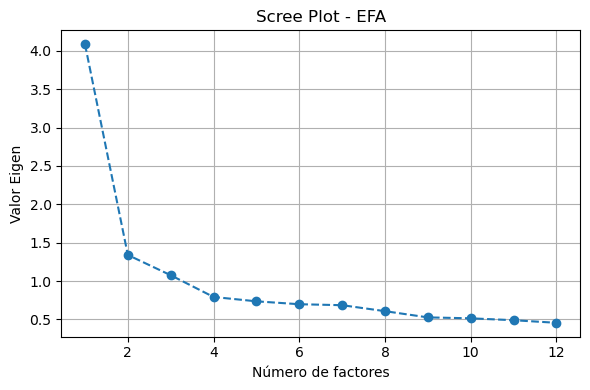

Cargas factoriales (array con nombres):

sk1    -> [ 0.032  0.603 -0.039]
sk2    -> [0.013 0.511 0.195]
sk3    -> [ 0.011  0.648 -0.016]
sk4    -> [-0.002  0.747 -0.01 ]
sk5    -> [-0.031  0.02   0.81 ]
sk6    -> [0.092 0.101 0.414]
sk8    -> [ 0.232 -0.069  0.453]
sk9    -> [0.501 0.083 0.052]
sk10   -> [ 0.62  -0.027 -0.035]
sk11   -> [0.703 0.033 0.009]
sk12   -> [ 0.575 -0.034  0.006]
sk13   -> [ 0.514  0.027 -0.008]

Comunalidades:

sk1    -> 0.366
sk2    -> 0.299
sk3    -> 0.421
sk4    -> 0.559
sk5    -> 0.658
sk6    -> 0.19
sk8    -> 0.264
sk9    -> 0.26
sk10   -> 0.386
sk11   -> 0.495
sk12   -> 0.332
sk13   -> 0.265

Varianza explicada por cada factor:
Varianza: [1.788 1.629 1.077]
Proporción: [0.149 0.136 0.09 ]
Proporción acumulada: [0.149 0.285 0.375]

Variables agrupadas por factor (carga > 0.3):
Factor 1: ['sk9', 'sk10', 'sk11', 'sk12', 'sk13']
Factor 2: ['sk1', 'sk2', 'sk3', 'sk4']
Factor 3: ['sk5', 'sk6', 'sk8']


In [4]:
# === Paso 1: Variables ===
# Ya se invirtió sk7 previamente, pero no aporta al modelo, por eso se excluye
sk_vars = [f'sk{i}' for i in range(1, 14)]
sk_vars.remove('sk7')
df_sk = df[sk_vars]

# === Paso 2: EFA preliminar (sin fijar n_factors) para obtener eigenvalores ===
fa = FactorAnalyzer(rotation='oblimin')  
fa.fit(df_sk)

# === Paso 3: Scree Plot para decidir n_factors ===
eigenvalues, _ = fa.get_eigenvalues()

# === Scree Plot más pequeño para EFA ===
plt.figure(figsize=(6, 4))  # Tamaño reducido
plt.plot(range(1, len(eigenvalues)+1), eigenvalues, marker='o', linestyle='--')
plt.title('Scree Plot - EFA', fontsize=12)
plt.xlabel('Número de factores', fontsize=10)
plt.ylabel('Valor Eigen', fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()


# === Paso 4: EFA final con número óptimo de factores (e.g. 3) ===
fa = FactorAnalyzer(n_factors=3, rotation='oblimin')
fa.fit(df_sk)

# === Paso 5: Mostrar matriz de cargas factoriales (tipo array, pero con nombres y redondeo) ===
loadings = np.round(fa.loadings_, 3)
print("Cargas factoriales (array con nombres):\n")
for i, var in enumerate(sk_vars):
    print(f"{var:6s} -> {loadings[i]}")

# === Paso 6: Comunalidades ===
communalities = np.round(fa.get_communalities(), 3)
print("\nComunalidades:\n")
for var, com in zip(sk_vars, communalities):
    print(f"{var:6s} -> {com}")

# === Paso 7: Varianza explicada ===
variance = fa.get_factor_variance()
print("\nVarianza explicada por cada factor:")
print("Varianza:", np.round(variance[0], 3))
print("Proporción:", np.round(variance[1], 3))
print("Proporción acumulada:", np.round(variance[2], 3))

# === Paso 8: Agrupación de variables por factor (carga > 0.3) ===
print("\nVariables agrupadas por factor (carga > 0.3):")
for i in range(loadings.shape[1]):
    grupo = [sk_vars[j] for j in range(len(sk_vars)) if loadings[j, i] > 0.3]
    print(f"Factor {i+1}: {grupo}")

#### 3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

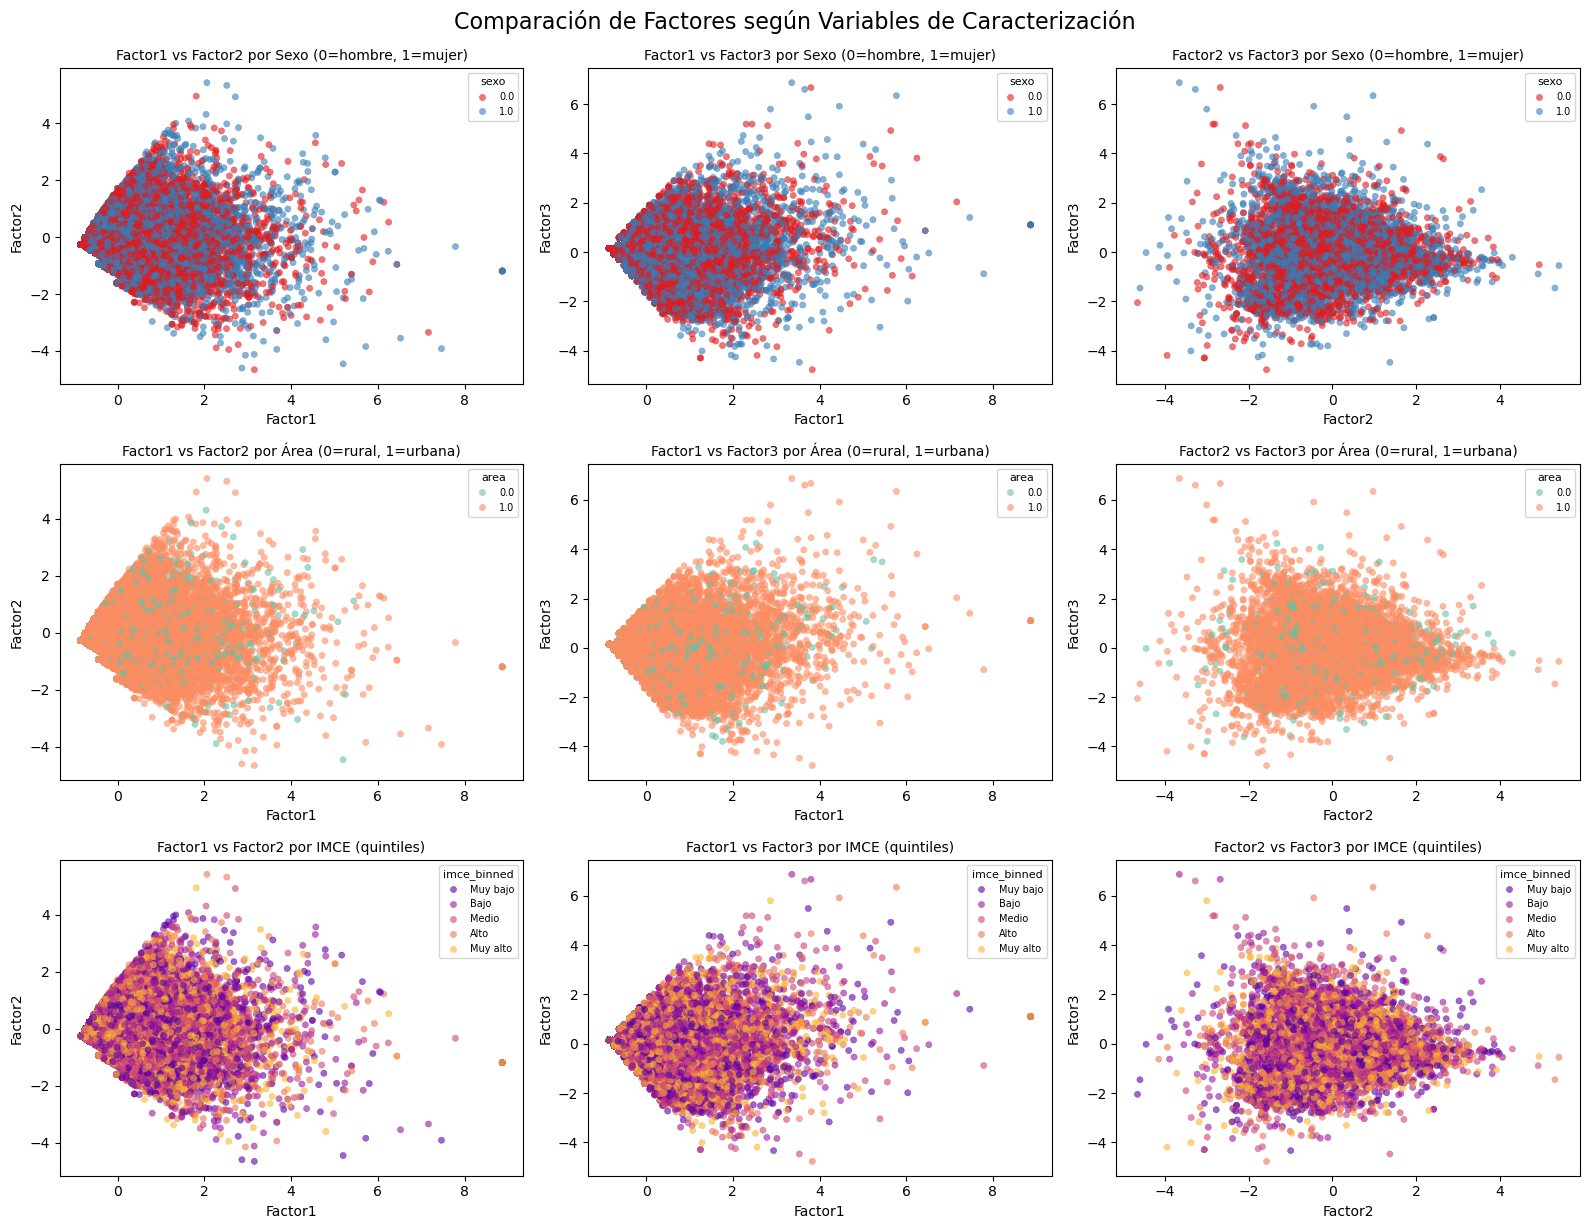

In [5]:
# # Esto es necesario ya que FactorAnalysis es sensible a las escalas originales
X_scaled = sklearn.preprocessing.StandardScaler().fit_transform(df[sk_vars])

# # Se aplica Análisis Factorial para obtener las puntuaciones de los 3 factores
# # Esta salida será utilizada en las visualizaciones
fa_model = sklearn.decomposition.FactorAnalysis(n_components=3)
factor_scores = fa_model.fit_transform(X_scaled)

# # Se crea el DataFrame con los factores y variables de caracterización
df_factors = pd.DataFrame(factor_scores, columns=['Factor1', 'Factor2', 'Factor3'])
df_factors['sexo'] = df['sexo']
df_factors['area'] = df['area']
df_factors['imce'] = df['imce']
df_factors['act_fisica'] = df['act_fisica']

# # Se clasifica la variable IMCE en quintiles para facilitar su interpretación en gráficos
# # Esto evita la sobresaturación visual que genera un gradiente continuo
df_factors['imce_binned'] = pd.qcut(df_factors['imce'], q=5, labels=['Muy bajo', 'Bajo', 'Medio', 'Alto', 'Muy alto'])

# # Se definen los pares de factores a graficar
# # Se grafican todas las combinaciones posibles entre los tres factores obtenidos
pairs = [('Factor1', 'Factor2'), ('Factor1', 'Factor3'), ('Factor2', 'Factor3')]

# # Se establecen las variables de caracterización con sus etiquetas y paletas de colores
# # Incluye variables categóricas binarias y ordinales (sexo, área, IMCE clasificado)
caracteristicas = [
    ('sexo', 'Sexo (0=hombre, 1=mujer)', 'Set1'),
    ('area', 'Área (0=rural, 1=urbana)', 'Set2'),
    ('imce_binned', 'IMCE (quintiles)', 'plasma')
]

# # Se crea una figura de 3x3 subplots para presentar los 9 gráficos en una sola vista
# # Esto mejora la legibilidad y permite comparar fácilmente las distribuciones
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

# # Se recorre cada variable de caracterización y cada par de factores
# # Se genera un scatterplot para visualizar cómo se distribuyen los factores según cada variable
for i, (cat, cat_label, palette) in enumerate(caracteristicas):
    for j, (x, y) in enumerate(pairs):
        idx = i * 3 + j
        ax = axes[idx]
        sns.scatterplot(
            data=df_factors,
            x=x, y=y,
            hue=cat,
            palette=palette,
            s=20, alpha=0.6,
            ax=ax,
            edgecolor=None
        )
        ax.set_title(f"{x} vs {y} por {cat_label}", fontsize=10)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
        ax.legend(title=cat, fontsize=7, title_fontsize=8, loc='best')

# # Se ajusta la distribución de los subgráficos y se establece un título general
# # Esto permite ver de forma clara las relaciones entre factores y grupos sociales o físicos
plt.tight_layout()
plt.suptitle('Comparación de Factores según Variables de Caracterización', fontsize=16, y=1.02)
plt.show()


#### 4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). 

Modelo con semopy:
Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.141
Number of iterations: 42
Params: 1.332 1.231 1.092 1.259 1.793 1.603 1.777 1.028 1.156 0.055 0.063 0.160 0.057 0.097 0.165 0.100 0.601 0.204 0.448 0.716 0.245 0.201 0.160 0.154 0.376 0.476 0.283

Cargas estandarizadas y parámetros del modelo:


,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,exploracion,1.000000,0.601100,-,-,-
1,sk10,~,exploracion,1.332470,0.566705,0.017634,75.563294,0.0
2,sk11,~,exploracion,1.230549,0.736758,0.013975,88.055728,0.0
3,sk12,~,exploracion,1.092187,0.546790,0.014833,73.633298,0.0
4,sk13,~,exploracion,1.259375,0.511775,0.017972,70.072708,0.0
5,sk1,~,afecto,1.000000,0.596182,-,-,-
6,sk2,~,afecto,1.792838,0.647813,0.021592,83.034412,0.0
7,sk3,~,afecto,1.603236,0.642985,0.019398,82.648306,0.0
8,sk4,~,afecto,1.776736,0.721947,0.020169,88.091097,0.0
9,sk5,~,interaccion,1.000000,0.719456,-,-,-



Correlaciones entre factores (estandarizadas):


,lval,rval,Est. Std
13,afecto,interaccion,0.657339
15,exploracion,afecto,0.603889
16,exploracion,interaccion,0.594121



Indicadores de ajuste del modelo:


,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4376.541525,0.0,87441.516886,0.950495,0.949949,0.935228,0.949949,0.935934,0.052315,53.71756,278.936768,0.14122


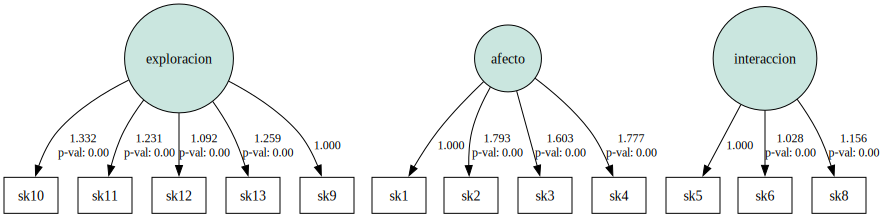

In [6]:
# === 1. Definir modelo CFA según los factores del EFA ===
modelo_cfa = """
exploracion =~ sk9 + sk10 + sk11 + sk12 + sk13
afecto       =~ sk1 + sk2 + sk3 + sk4
interaccion  =~ sk5 + sk6 + sk8
"""

# === 2. Ajuste del modelo con semopy ===
modelo = semopy.Model(modelo_cfa)
out=modelo.fit(df_sk)
print("Modelo con semopy:")
print(out)

# === 3. Tabla con cargas estandarizadas y otros parámetros del modelo ===
tabla_cargas = modelo.inspect(std_est=True)
print("\nCargas estandarizadas y parámetros del modelo:")
display(tabla_cargas)

# === 4. Extraer correlaciones entre factores (filas con '~~' entre factores) ===
correlaciones = tabla_cargas[
    (tabla_cargas['op'] == '~~') &
    (tabla_cargas['lval'].isin(['exploracion', 'afecto', 'interaccion'])) &
    (tabla_cargas['rval'].isin(['exploracion', 'afecto', 'interaccion'])) &
    (tabla_cargas['lval'] != tabla_cargas['rval'])
]
print("\nCorrelaciones entre factores (estandarizadas):")
display(correlaciones[['lval', 'rval', 'Est. Std']])

# === 5. Métricas de ajuste global del modelo ===
ajuste = semopy.calc_stats(modelo)
print("\nIndicadores de ajuste del modelo:")
display(ajuste)

#6: Graficar
semopy.semplot(modelo, "semmodel.png")

#### 5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

Fitting StepMix...


Initializations (n_init) : 100%|█████████████████████| 1/1 [00:00<00:00, 167.11it/s, max_LL=-5.76e+4, max_avg_LL=-1.86]


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:01<00:00,  1.02s/it, max_LL=-5.41e+4, max_avg_LL=-1.75]


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:02<00:00,  2.69s/it, max_LL=-5.36e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:07<00:00,  7.18s/it, max_LL=-5.36e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:10<00:00, 10.11s/it, max_LL=-5.36e+4, max_avg_LL=-1.73]


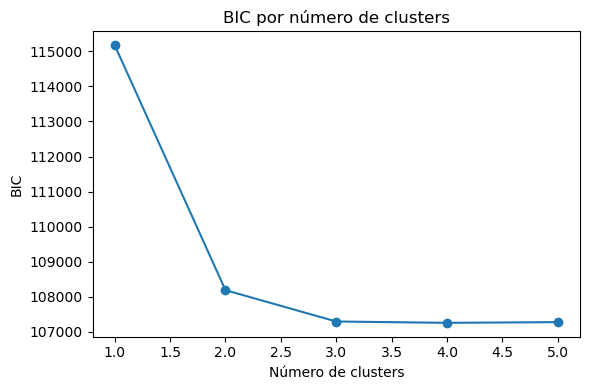

Fitting StepMix...


Initializations (n_init) : 100%|██████████████████████| 1/1 [00:02<00:00,  2.70s/it, max_LL=-5.36e+4, max_avg_LL=-1.73]


MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            2.4089  0.5933 -1.9638
    Class weights
        Class 1 : 0.27
        Class 2 : 0.71
        Class 3 : 0.02
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 30991
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -53622.8190
    -2LL                          : 107245.6381
    Average LL                    : -1.7303
    AIC                           : 107255.64
    BIC                           : 107297.35
    CAIC                          : 107302.35
    Sample-Size Adjusted BIC      : 107333.16
    Entropy                       : 11925.1396
    Scaled Relative Entropy       : 0.6497
MODEL REPORT
    Measurement model paramete

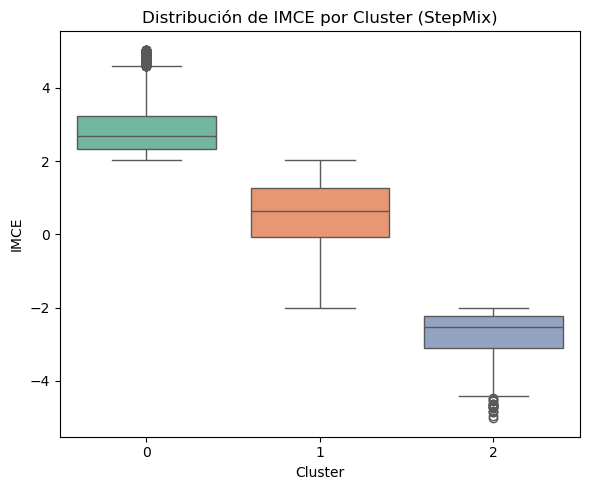

In [7]:
from stepmix.stepmix import StepMix
# Paso 1: Selección de IMCE
df_imce = df[['imce']].dropna()

# Paso 2: BIC para diferentes clusters
k_range = range(1, 6)
bic_scores = []
modelos = []

for k in k_range:
    modelo = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123)
    modelo.fit(df_imce)
    modelos.append(modelo)
    bic_scores.append(modelo.bic(df_imce))

# Paso 3: Visualizar BIC con un lineplot
plt.figure(figsize=(6, 4))
plt.plot(k_range, bic_scores, marker='o')
plt.title("BIC por número de clusters")
plt.xlabel("Número de clusters")
plt.ylabel("BIC")
plt.tight_layout()
plt.show()

# Paso 4: Ajuste del modelo con el mejor número de clusters (k=3)
modelo = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)
modelo.fit(df_imce)

# Paso 5: Mostrar reporte estándar del modelo (sin include)
print(modelo.report(df_imce))  # <--- solo así, sin argumentos extra

# Paso 6: Agregar predicción al mismo df_imce
df_imce['pred'] = modelo.predict(df_imce)

# Paso 7: guardar en el df original 
df['cluster_imce'] = df_imce['pred'].values

# Paso 8: Visualizar distribución con boxplot
plt.figure(figsize=(6, 5))
sns.boxplot(x='pred', y='imce', data=df_imce, palette='Set2')
plt.title('Distribución de IMCE por Cluster (StepMix)')
plt.xlabel('Cluster')
plt.ylabel('IMCE')
plt.tight_layout()
plt.show()


#### 6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

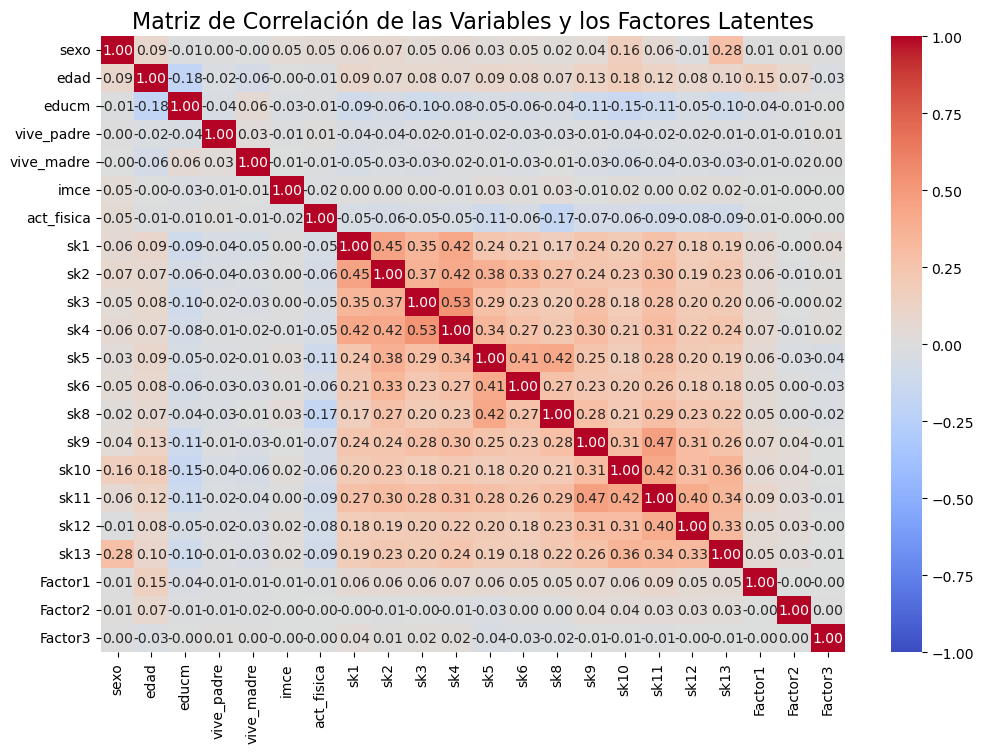

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.335
Number of iterations: 51
Params: 1.331 1.229 1.090 1.258 1.796 1.604 1.779 1.028 1.157 -0.019 -0.291 0.234 0.134 -0.160 -0.026 0.030 -0.003 -0.078 0.055 0.063 0.161 0.057 0.097 1.867 0.165 0.100 0.601 0.204 0.448 0.716 0.245 0.201 0.160 0.154 0.376 0.476 0.283


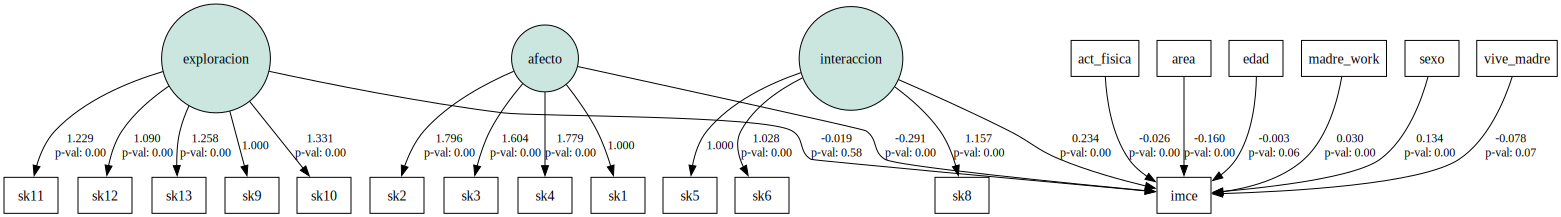

In [13]:
# Filtrar columnas relevantes para el modelo
variables = [
    'sexo', 'edad', 'educm', 'vive_padre', 'vive_madre', 
    'imce', 'act_fisica', 
    'sk1','sk2','sk3','sk4','sk5','sk6','sk8','sk9','sk10','sk11','sk12','sk13'
]

# Concatenar los factores latentes con las demás variables para la matriz de correlación
df_full = pd.concat([df_sem, df_factors[['Factor1', 'Factor2', 'Factor3']]], axis=1)

# Calcular la matriz de correlación
corr_matrix = df_full.corr()

# Crear un heatmap de la matriz de correlación
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlación de las Variables y los Factores Latentes", fontsize=16)
plt.show()
mod_cf = '''
#Measurement
exploracion =~ sk9 + sk10 + sk11 + sk12 + sk13
afecto       =~ sk1 + sk2 + sk3 + sk4
interaccion  =~ sk5 + sk6 + sk8

#Structural
imce ~ exploracion + afecto + interaccion + sexo + area + act_fisica + madre_work + edad + vive_madre
'''

model_cfa = semopy.Model(mod_cf);
out = model_cfa.fit(df);
print(out)
semopy.semplot(model_cfa, "semmodel.png")

#### 7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?  

In [18]:
# Crear una lista para almacenar los resultados de cada clase
resultados_clases = []

# Recorrer las clases latentes (clusters) y ajustar el modelo SEM para cada una
for cls in df['cluster_imce'].unique():  # Usamos los valores de la columna 'cluster_imce' directamente
    # Filtrar el dataframe según la clase latente
    df_clase = df[df['cluster_imce'] == cls]
    
    # Ajustar el modelo SEM para esta clase
    model_cfa = semopy.Model(mod_cf)
    out = model_cfa.fit(df_clase)
    
    # Almacenar los resultados
    resultados_clases.append((cls, model_cfa))
    
    # Mostrar los resultados
    print(f"Resultados para la clase {cls}:")
    print(out)
    
    # Graficar el modelo SEM para la clase latente
    semopy.semplot(model_cfa, f"sem_model_clase_{cls}.png")

# Comparar los resultados de los diferentes grupos
for cls, model in resultados_clases:
    print(f"Resumen de resultados para la clase {cls}:")
    # Inspeccionar los parámetros del modelo
    params = model.inspect()
    print(params[['lval', 'op', 'rval', 'Estimate']])
    

Resultados para la clase 1:
Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.334
Number of iterations: 43
Params: 1.334 1.235 1.084 1.241 1.810 1.643 1.822 1.046 1.172 -0.013 -0.048 0.020 -0.018 -0.067 -0.005 0.016 -0.004 -0.072 0.053 0.060 0.157 0.056 0.093 0.821 0.156 0.100 0.591 0.201 0.443 0.708 0.244 0.197 0.160 0.150 0.370 0.461 0.285
Resultados para la clase 0:
Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.373
Number of iterations: 40
Params: 1.336 1.222 1.134 1.319 1.717 1.466 1.610 0.978 1.107 -0.018 -0.144 0.149 0.184 -0.010 -0.004 -0.020 -0.005 0.042 0.065 0.072 0.168 0.061 0.108 0.446 0.195 0.100 0.632 0.214 0.467 0.739 0.249 0.215 0.159 0.168 0.394 0.520 0.275
Resultados para la clase 2:
Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective v